In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns


In [2]:
# Tải dữ liệu
from google.colab import files
files.upload()

Saving superstore_data.csv to superstore_data.csv


{'superstore_data.csv': b'Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain\r\n1826,1970,Graduation,Divorced,84835,0,0,6/16/2014,0,189,104,379,111,189,218,1,4,4,6,1,1,0\r\n1,1961,Graduation,Single,57091,0,0,6/15/2014,0,464,5,64,7,0,37,1,7,3,7,5,1,0\r\n10476,1958,Graduation,Married,67267,0,1,5/13/2014,0,134,11,59,15,2,30,1,3,2,5,2,0,0\r\n1386,1967,Graduation,Together,32474,1,1,11/5/2014,0,10,0,1,0,0,0,1,1,0,2,7,0,0\r\n5371,1989,Graduation,Single,21474,1,0,8/4/2014,0,6,16,24,11,0,34,2,3,1,2,7,1,0\r\n7348,1958,PhD,Single,71691,0,0,3/17/2014,0,336,130,411,240,32,43,1,4,7,5,2,1,0\r\n4073,1954,2n Cycle,Married,63564,0,0,1/29/2014,0,769,80,252,15,34,65,1,10,10,7,6,1,0\r\n1991,1967,Graduation,Together,44931,0,1,1/18/2014,0,78,0,11,0,0,7,1,2,1,3,5,0,0\r\n4047,1954,PhD,Married,

In [3]:
df = data = pd.read_csv('superstore_data.csv')
df

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,7/3/2013,99,372,...,47,48,78,2,5,2,11,4,0,0
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,16,1,1,0,3,8,0,0
2237,22,1976,Graduation,Divorced,46310.0,1,0,3/12/2012,99,185,...,15,5,14,2,6,1,5,8,0,0
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,149,165,63,1,5,4,10,3,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# **1. Làm sạch dữ liệu**

In [7]:
# --- BƯỚC 1: DROP CÁC HÀNG/CỘT KHÔNG CẦN THIẾT ---
# Đặt cột Id làm index thay vì xóa bỏ
df.set_index('Id', inplace=True)

# Loại bỏ các hàng có năm sinh bất thường (< 1920)
df = df[df['Year_Birth'] >= 1920]


# --- BƯỚC 2: THAY ĐỔI KIỂU DỮ LIỆU ---
# Chuyển cột Dt_Customer sang định dạng datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])


# --- BƯỚC 3: DROP CÁC HÀNG BỊ TRÙNG LẶP ---
df.drop_duplicates(inplace=True)


# --- BƯỚC 4 & 5: XỬ LÝ DỮ LIỆU KHUYẾT THIẾU (Cột Income) ---
# Lựa chọn: Điền bằng giá trị trung vị (Median) vì tối ưu nhất cho tập dữ liệu này
income_median = df['Income'].median()
df['Income'].fillna(income_median, inplace=True)

/tmp/ipykernel_3316/1872443918.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
/tmp/ipykernel_3316/1872443918.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)
/tmp/ipykernel_3316/1872443918.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [8]:
# Kiểm tra lại kết quả sau khi làm sạch
print("Kích thước dữ liệu sau khi làm sạch:", df.shape)
print("Số giá trị khuyết còn lại:\n", df.isnull().sum().sum())

Kích thước dữ liệu sau khi làm sạch: (2055, 21)
Số giá trị khuyết còn lại:
 0


# **2. Trực quan hóa dữ liệu**

**Cấu hình chung**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình chung cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Đọc và làm sạch nhanh dữ liệu đầu vào
df = pd.read_csv('superstore_data.csv')
df = df[df['Year_Birth'] >= 1920]
df['Income'] = df['Income'].fillna(df['Income'].median())
df_clean = df[df['Income'] < 200000].copy() # Loại bỏ outlier thu nhập để vẽ biểu đồ chính xác

**Câu 1: Phân phối mức thu nhập (Income) của khách hàng**
<br>
Trả lời: Thu nhập của khách hàng tập trung chủ yếu ở phân khúc từ 35.000 đến 68.000, với mức trung vị (Median) khoảng 51.373.

Biểu đồ phù hợp: Histogram kết hợp đường cong mật độ (KDE).

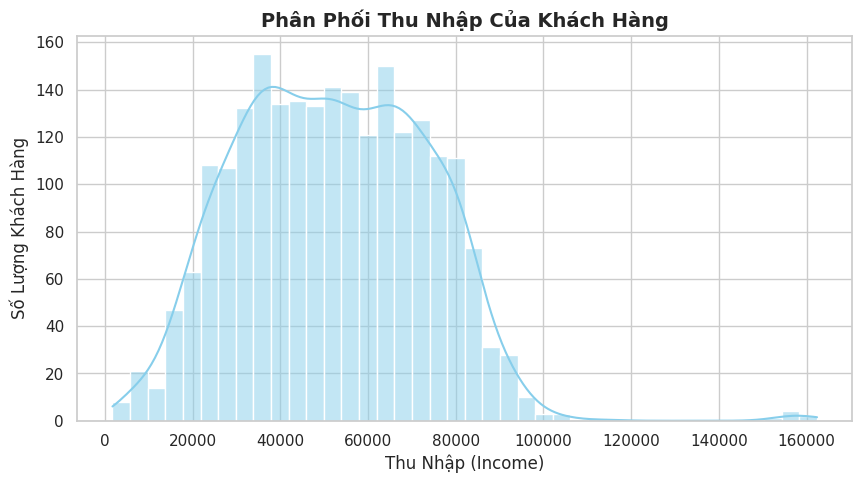

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Income'], kde=True, color='skyblue', bins=40)
plt.title('Phân Phối Thu Nhập Của Khách Hàng', fontsize=14, fontweight='bold')
plt.xlabel('Thu Nhập (Income)')
plt.ylabel('Số Lượng Khách Hàng')
plt.show()

**Câu 2: Mối tương quan giữa Thu nhập và Tiền chi tiêu cho Rượu (MntWines)**
<br>
Trả lời: Có một mối tương quan thuận khá mạnh (hệ số tương quan $r \approx 0.69$). Khách hàng có thu nhập càng cao thì lượng tiền chi tiêu cho rượu càng lớn.Biểu đồ phù hợp: Scatter Plot (Biểu đồ phân tán) kèm đường xu hướng (Regression Line).

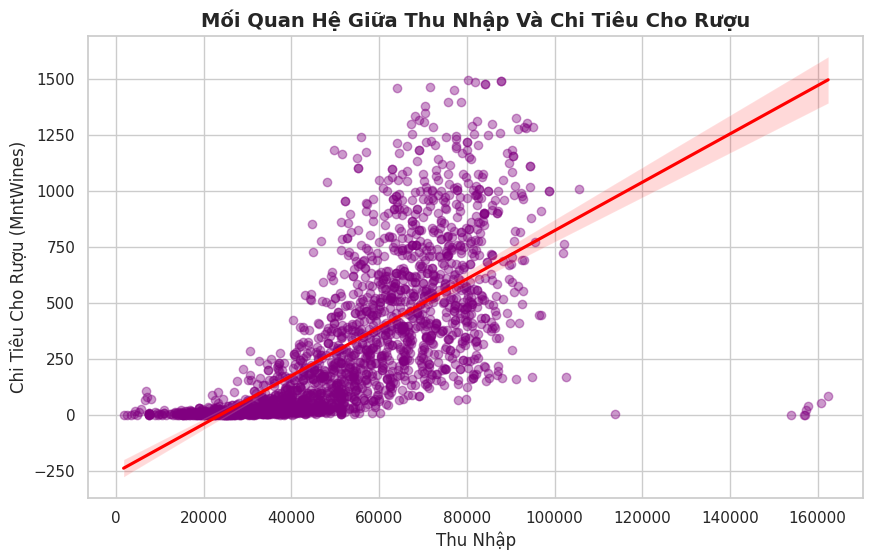

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='Income', y='MntWines', scatter_kws={'alpha':0.4, 'color':'purple'}, line_kws={'color':'red'})
plt.title('Mối Quan Hệ Giữa Thu Nhập Và Chi Tiêu Cho Rượu', fontsize=14, fontweight='bold')
plt.xlabel('Thu Nhập')
plt.ylabel('Chi Tiêu Cho Rượu (MntWines)')
plt.show()

**Câu 3: So sánh lượng mua hàng qua các kênh (Web, Catalog, Store)**
<br>
Trả lời: Khách hàng ưu tiên mua trực tiếp tại cửa hàng nhiều nhất (Trung bình 5.79 lần), tiếp theo là mua qua Web (4.08 lần) và thấp nhất là qua Catalog (2.66 lần).

Biểu đồ phù hợp: Bar chart (Biểu đồ cột) so sánh giá trị trung bình.

/tmp/ipykernel_3316/1973683771.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(channels.keys()), y=list(channels.values()), palette='pastel')


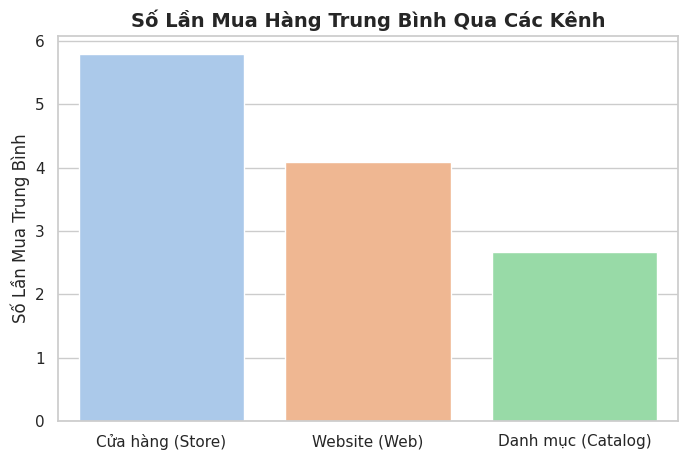

In [12]:
channels = {'Cửa hàng (Store)': df['NumStorePurchases'].mean(),
            'Website (Web)': df['NumWebPurchases'].mean(),
            'Danh mục (Catalog)': df['NumCatalogPurchases'].mean()}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(channels.keys()), y=list(channels.values()), palette='pastel')
plt.title('Số Lần Mua Hàng Trung Bình Qua Các Kênh', fontsize=14, fontweight='bold')
plt.ylabel('Số Lần Mua Trung Bình')
plt.show()

**Câu 4: Cơ cấu tổng chi tiêu theo nhóm sản phẩm**
<br>
Trả lời: Rượu (Wines) chiếm tỷ trọng áp đảo lớn nhất trong tổng chi tiêu của siêu thị, tiếp theo là Thịt (Meat). Các mặt hàng như Trái cây, Cá, Đồ ngọt có tỷ trọng rất nhỏ.

Biểu đồ phù hợp: Biểu đồ tròn (Pie Chart) thể hiện thị phần/cơ cấu.

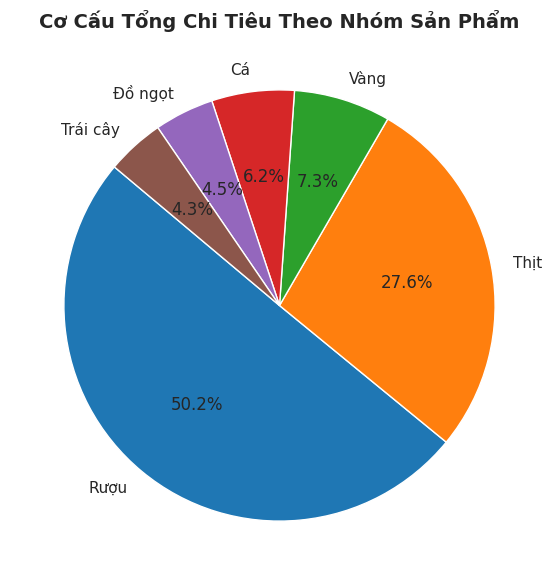

In [16]:
products = {
    'Rượu': df['MntWines'].sum(),
    'Thịt': df['MntMeatProducts'].sum(),
    'Vàng': df['MntGoldProds'].sum(),
    'Cá': df['MntFishProducts'].sum(),
    'Đồ ngọt': df['MntSweetProducts'].sum(),
    'Trái cây': df['MntFruits'].sum()
}

# Get the number of categories for the color palette
n_categories = len(products)

# Generate a color palette with the correct number of colors using 'tab10'
colors = sns.color_palette('tab10', n_colors=n_categories)

plt.figure(figsize=(7, 7))
plt.pie(products.values(), labels=products.keys(), autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Cơ Cấu Tổng Chi Tiêu Theo Nhóm Sản Phẩm', fontsize=14, fontweight='bold')
plt.show()

**Câu 5: Phân bố Trình độ học vấn (Education) của khách hàng**
<br>
Trả lời: Khách hàng có trình độ Graduation (Cử nhân/Tốt nghiệp đại học) chiếm đa số tuyệt đối với hơn 50%, tiếp theo là PhD (Tiến sĩ) khoảng 21.6% và Master (Thạc sĩ) khoảng 16.5%.

Biểu đồ phù hợp: Countplot (Biểu đồ đếm tần suất thanh ngang hoặc đứng).

/tmp/ipykernel_3316/1858485125.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Education', order=df['Education'].value_counts().index, palette='viridis')


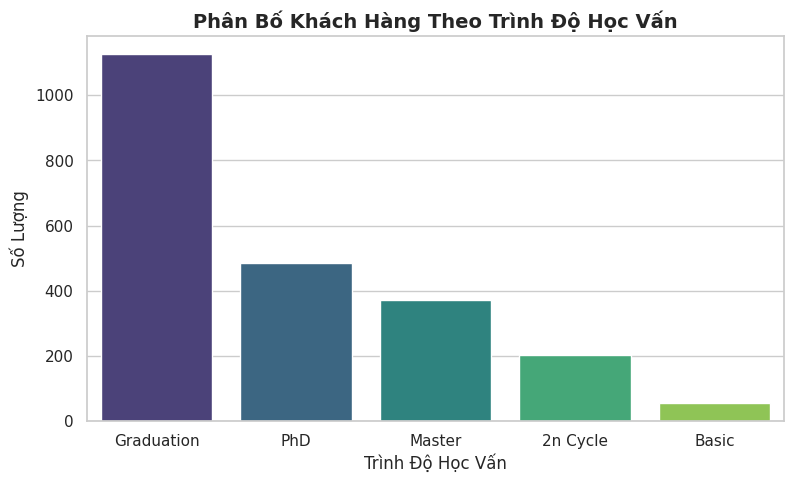

In [17]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Education', order=df['Education'].value_counts().index, palette='viridis')
plt.title('Phân Bố Khách Hàng Theo Trình Độ Học Vấn', fontsize=14, fontweight='bold')
plt.xlabel('Trình Độ Học Vấn')
plt.ylabel('Số Lượng')
plt.show()

**Câu 6: Tình trạng hôn nhân (Marital_Status) phổ biến**
<br>
Trả lời: Nhóm khách hàng đã kết hôn (Married) chiếm số lượng đông nhất, tiếp theo là nhóm sống chung (Together) và độc thân (Single). Có xuất hiện một số nhãn nhiễu rất nhỏ như 'YOLO', 'Absurd' có thể gom nhóm lại hoặc bỏ qua khi phân tích nâng cao.

Biểu đồ phù hợp: Countplot.

/tmp/ipykernel_3316/1811930833.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Marital_Status', order=df['Marital_Status'].value_counts().index, palette='magma')


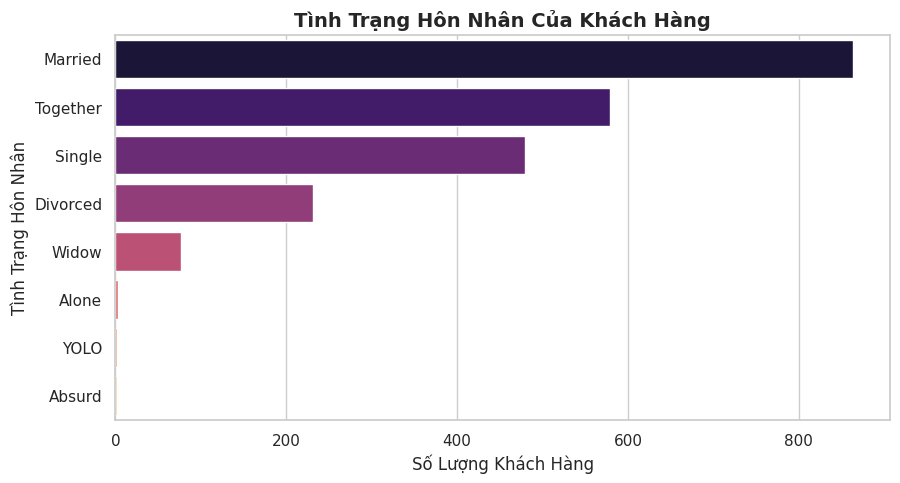

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Marital_Status', order=df['Marital_Status'].value_counts().index, palette='magma')
plt.title('Tình Trạng Hôn Nhân Của Khách Hàng', fontsize=14, fontweight='bold')
plt.xlabel('Số Lượng Khách Hàng')
plt.ylabel('Tình Trạng Hôn Nhân')
plt.show()

**Câu 7: Tỷ lệ khách hàng phản hồi (Response) chiến dịch**
<br>
Trả lời: Phần lớn khách hàng từ chối hoặc không tương tác với chiến dịch mới (85.1% chọn 0), chỉ có 14.9% khách hàng phản hồi tích cực (1).

Biểu đồ phù hợp: Pie Chart hoặc Donut Chart.

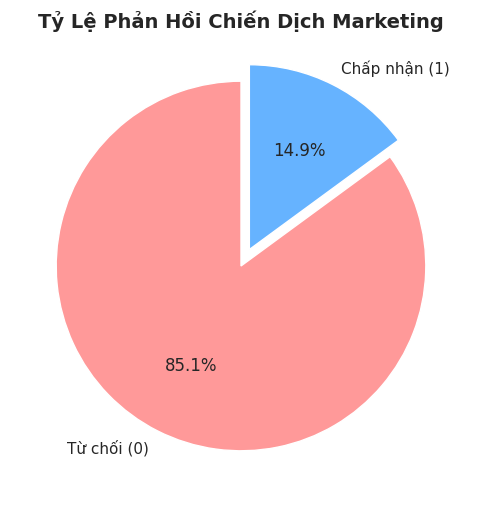

In [19]:
response_counts = df['Response'].value_counts()
labels = ['Từ chối (0)', 'Chấp nhận (1)']

plt.figure(figsize=(6, 6))
plt.pie(response_counts, labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], explode=(0, 0.1), startangle=90)
plt.title('Tỷ Lệ Phản Hồi Chiến Dịch Marketing', fontsize=14, fontweight='bold')
plt.show()

**Câu 8: Trình độ học vấn ảnh hưởng thế nào tới Thu nhập (Income)?**
<br>
Trả lời: Nhóm có trình độ học vấn PhD (Tiến sĩ) có mức thu nhập trung vị cao nhất, trong khi nhóm có trình độ Basic (Cơ bản) có mức thu nhập thấp hơn hẳn so với các nhóm còn lại.

Biểu đồ phù hợp: Boxplot (Biểu đồ hộp) để xem phân phối thu nhập qua từng nhóm phân loại.

/tmp/ipykernel_3316/3930616996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Education', y='Income', palette='Set3', order=['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD'])


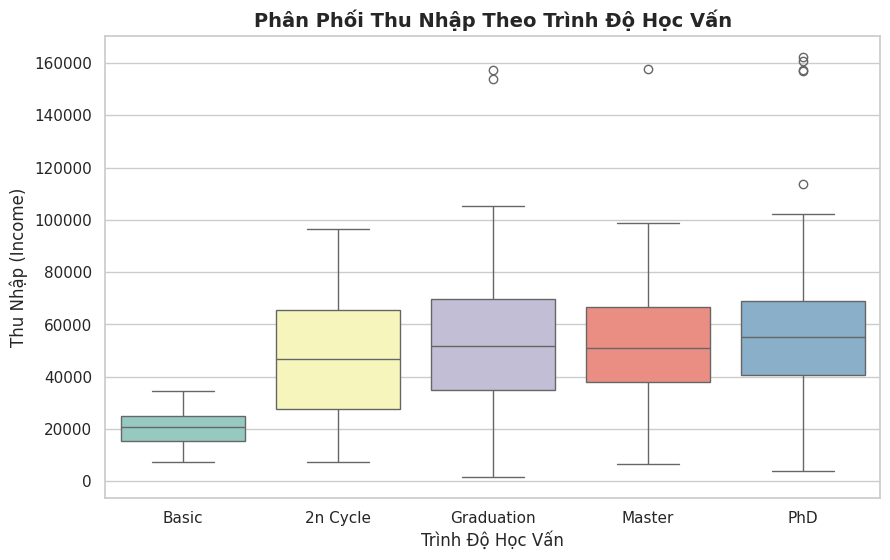

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Education', y='Income', palette='Set3', order=['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD'])
plt.title('Phân Phối Thu Nhập Theo Trình Độ Học Vấn', fontsize=14, fontweight='bold')
plt.xlabel('Trình Độ Học Vấn')
plt.ylabel('Thu Nhập (Income)')
plt.show()

**Câu 9: Có con nhỏ (Kidhome) ảnh hưởng thế nào tới tỷ lệ Phản hồi chiến dịch?**
<br>
Trả lời: Những hộ gia đình không có con nhỏ ở nhà (0 con) có tỷ lệ đồng ý nhận campaign cao nhất (~17.2%), tỷ lệ này giảm dần khi nhà có 1 con (~12.2%) và cực thấp nếu nhà có 2 con nhỏ (~4.1%). Khách hàng độc thân/chưa con nhỏ dễ tiếp cận marketing hơn.

Biểu đồ phù hợp: Barplot tỷ lệ phần trăm (Chỉ số trung bình của biến nhị phân Response).

/tmp/ipykernel_3316/161705687.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Kidhome', y='Response', ci=None, palette='crest')
/tmp/ipykernel_3316/161705687.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Kidhome', y='Response', ci=None, palette='crest')


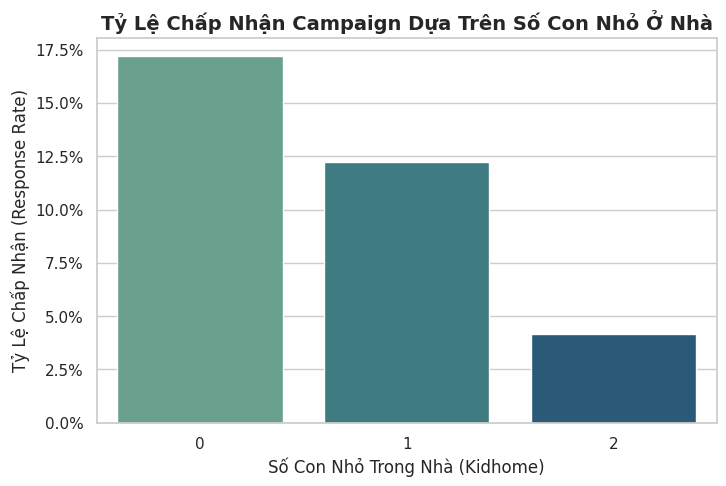

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Kidhome', y='Response', ci=None, palette='crest')
plt.title('Tỷ Lệ Chấp Nhận Campaign Dựa Trên Số Con Nhỏ Ở Nhà', fontsize=14, fontweight='bold')
plt.xlabel('Số Con Nhỏ Trong Nhà (Kidhome)')
plt.ylabel('Tỷ Lệ Chấp Nhận (Response Rate)')
# Định dạng trục Y thành %
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

# **3. Mô hình tuyến tính**

### Phân tích phân phối của các biến số chính

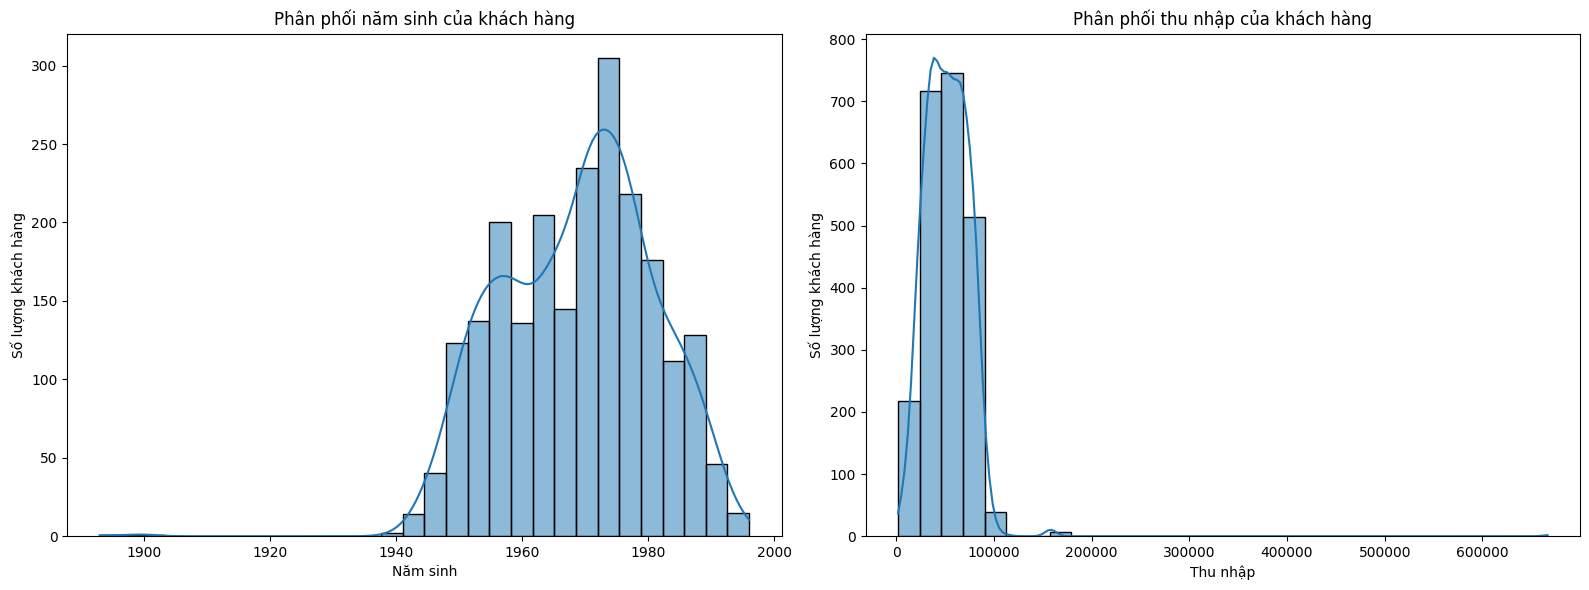

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['Year_Birth'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Phân phối năm sinh của khách hàng')
axes[0].set_xlabel('Năm sinh')
axes[0].set_ylabel('Số lượng khách hàng')

sns.histplot(df['Income'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Phân phối thu nhập của khách hàng')
axes[1].set_xlabel('Thu nhập')
axes[1].set_ylabel('Số lượng khách hàng')

plt.tight_layout()
plt.show()

### Xây dựng mô hình tuyến tính

Để dự đoán lượng rượu vang tiêu thụ (`MntWines`), chúng ta cần chọn các biến độc lập có thể ảnh hưởng đến nó. Trước tiên, hãy xem xét mối quan hệ giữa các biến số.

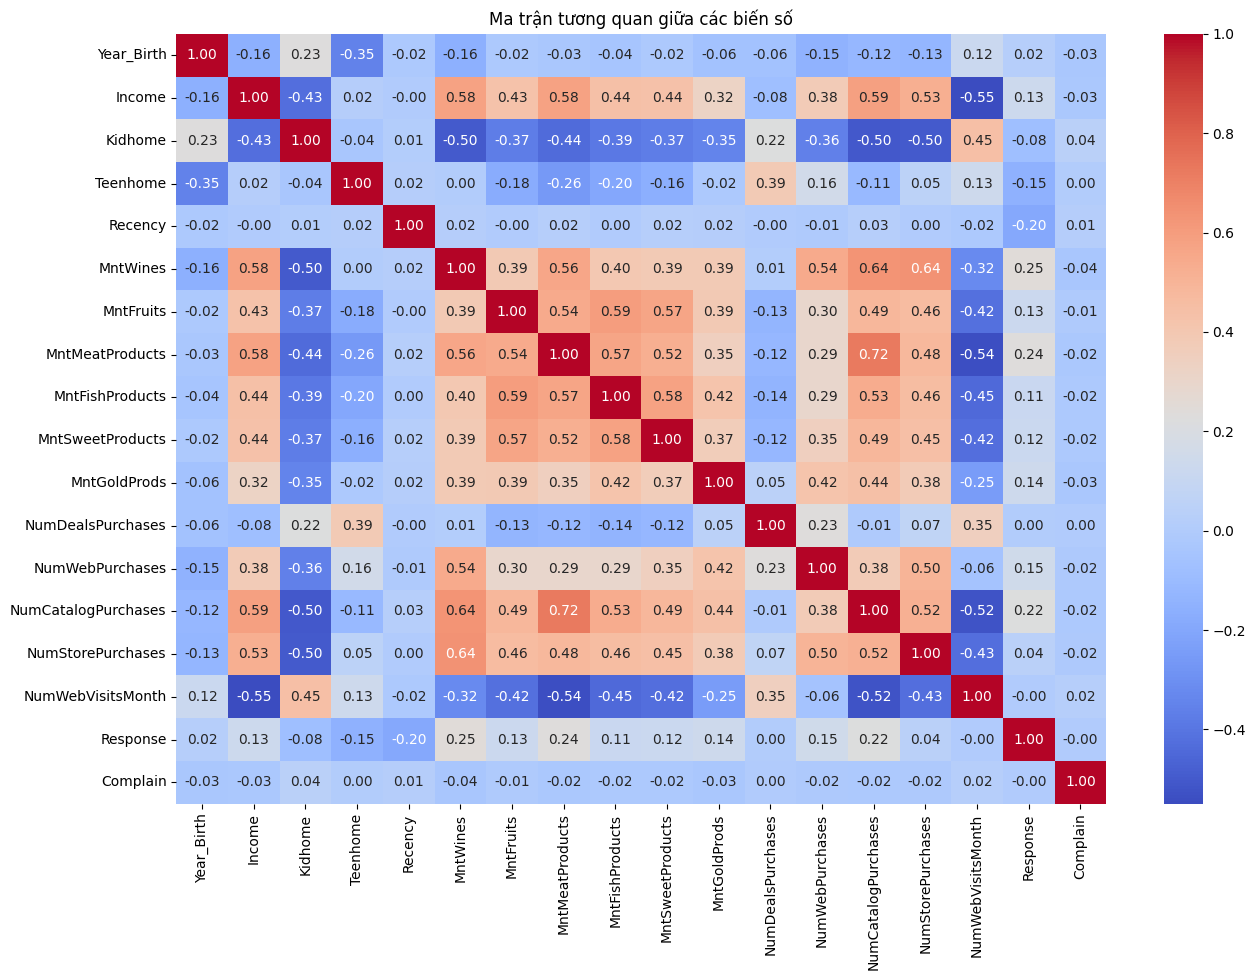

In [ ]:
df_numeric = df.select_dtypes(include=[np.number])

# Exclude 'Id' as it's just an identifier and not a feature.
# Exclude 'Recency' for now as it's a proxy for last purchase, not amount spent on wine.
# We will focus on spending habits and demographic information.
df_corr = df_numeric.drop(columns=['Id'])

plt.figure(figsize=(15, 10))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

# **4. Mô hình tuyến tính (p2)**

## **1. Xác định các biến độc lập và phụ thuộc**

Dựa trên kết quả phân tích tương quan ở bước trước, chúng ta thấy Thu nhập (Income) và Số tiền chi tiêu cho Rượu (MntWines) có mối quan hệ tuyến tính khá mạnh mẽ với nhau.
- Biến độc lập (Independent Variable - $X$): Income (Thu nhập của khách hàng). Chúng ta dùng thu nhập để dự đoán mức độ chi tiêu.
- Biến phụ thuộc (Dependent Variable - $y$): MntWines (Số tiền chi tiêu cho rượu). Đây là giá trị cần được dự đoán.

## **2. Vẽ biểu đồ nhiệt (Heatmap) để dự đoán mối quan hệ**

Để có cái nhìn tổng quan trước khi huấn luyện mô hình, chúng ta sẽ vẽ một Heatmap thể hiện hệ số tương quan giữa các biến số chính trong tập dữ liệu (Thu nhập, Các kênh mua sắm và Các nhóm sản phẩm tiêu dùng).

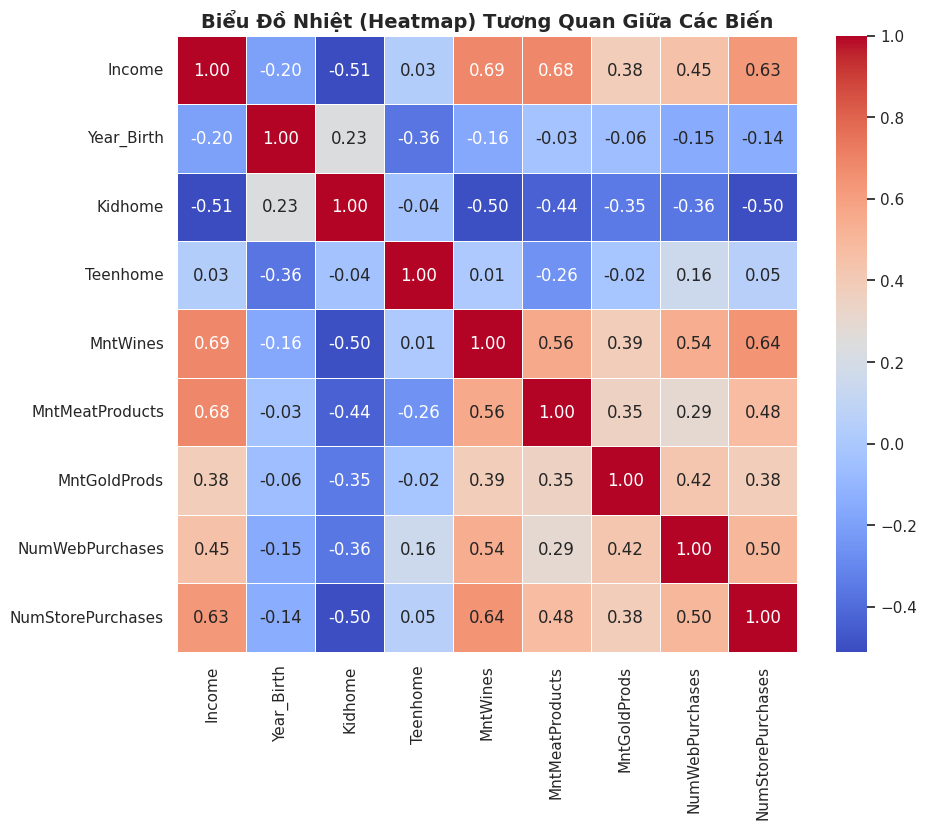

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Giả định dữ liệu df_clean đã loại bỏ outlier thu nhập > 200,000 từ bước trước
# Lựa chọn các biến quan trọng để đưa vào Heatmap
selected_cols = ['Income', 'Year_Birth', 'Kidhome', 'Teenhome',
                 'MntWines', 'MntMeatProducts', 'MntGoldProds',
                 'NumWebPurchases', 'NumStorePurchases']

corr_matrix = df_clean[selected_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Biểu Đồ Nhiệt (Heatmap) Tương Quan Giữa Các Biến', fontsize=14, fontweight='bold')
plt.show()

Nhận xét từ Heatmap: Cột Income và MntWines có hệ số tương quan là 0.69 (màu đỏ đậm ấm). Điều này chứng minh mối quan hệ tuyến tính đồng biến mạnh mẽ và hoàn toàn phù hợp để áp dụng thuật toán LinearRegression.

## **3. Áp dụng mô hình LinearRegression và Vẽ đường hồi quy**

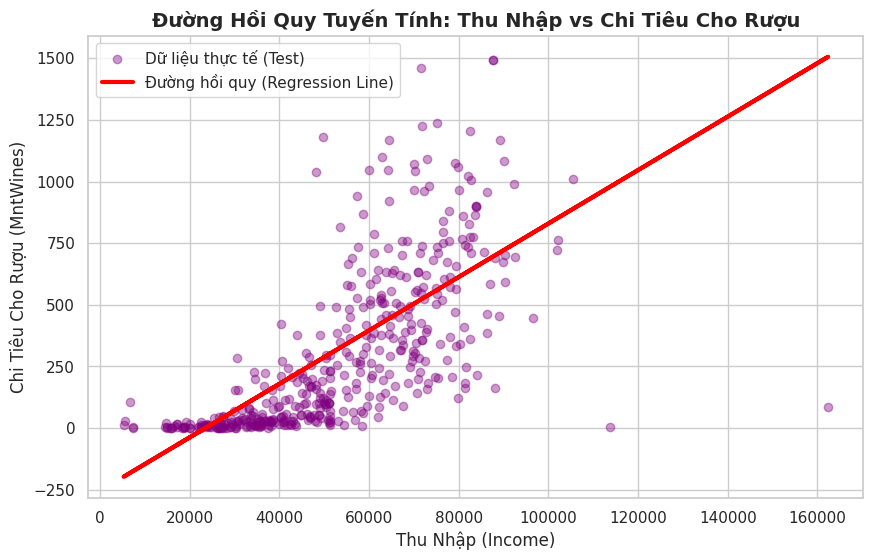

Phương trình hồi quy: MntWines = 0.0109 * Income + (-255.32)


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Tách biến X và y
X = df_clean[['Income']]
y = df_clean['MntWines']

# 2. Chia dữ liệu Train/Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Khởi tạo và huấn luyện mô hình
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Dự đoán trên tập kiểm thử
y_pred = model.predict(X_test)

# --- VẼ ĐƯỜNG HỒI QUY TUYẾN TÍNH ---
plt.figure(figsize=(10, 6))
# Vẽ các điểm dữ liệu thực tế của tập Test
plt.scatter(X_test, y_test, color='purple', alpha=0.4, label='Dữ liệu thực tế (Test)')
# Vẽ đường thẳng hồi quy mà mô hình học được
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Đường hồi quy (Regression Line)')

plt.title('Đường Hồi Quy Tuyến Tính: Thu Nhập vs Chi Tiêu Cho Rượu', fontsize=14, fontweight='bold')
plt.xlabel('Thu Nhập (Income)')
plt.ylabel('Chi Tiêu Cho Rượu (MntWines)')
plt.legend()
plt.show()

# In ra phương trình đường thẳng dạng: y = ax + b
print(f"Phương trình hồi quy: MntWines = {model.coef_[0]:.4f} * Income + ({model.intercept_:.2f})")

## **5. Đánh giá hiệu quả mô hình**

In [24]:
# Tính toán các chỉ số
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---")
print(f"Chỉ số R2 (R-squared)        : {r2:.4f}")
print(f"Sai số tuyệt đối tb (MAE)    : {mae:.2f}")
print(f"Sai số bình phương tb (MSE)  : {mse:.2f}")
print(f"Căn sai số bình phương (RMSE): {rmse:.2f}")

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---
Chỉ số R2 (R-squared)        : 0.4663
Sai số tuyệt đối tb (MAE)    : 169.44
Sai số bình phương tb (MSE)  : 56613.76
Căn sai số bình phương (RMSE): 237.94


Giải thích ý nghĩa các chỉ số:
- $R^2$ Score ($\approx 0.4663$): * Ý nghĩa: Biến Income (Thu nhập) giải thích được khoảng 46.63% sự biến động của biến MntWines (mức chi tiêu cho rượu). Đối với dữ liệu hành vi khách hàng thực tế (vốn chứa nhiều biến số ẩn ngẫu nhiên), mức $R^2$ gần 47% là một tín hiệu cho thấy mô hình tuyến tính có giá trị sử dụng khá tốt.
- MAE ($\approx 169.44$): * Ý nghĩa: Trung bình mỗi lần dự đoán, số tiền chi tiêu cho rượu bị lệch khoảng 169.44 đơn vị tiền tệ so với thực tế.
- RMSE ($\approx 237.94$): * Ý nghĩa: Do RMSE phạt nặng các lỗi dự đoán lớn (bằng cách bình phương lên rồi khai căn), việc RMSE cao hơn hẳn MAE cho thấy trong tập dữ liệu kiểm thử vẫn có một số khách hàng có hành vi chi tiêu đột biến (outliers) vượt xa mức dự đoán thông thường của mô hình tuyến tính.